In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (18, 6),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

In [2]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts_builder = TimeseriesBuilder()

In [3]:
start = NYC_tz.localize(datetime.datetime(2025, 1, 1, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 3, 27, 17, 00))

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="CT5/CT30",
            value=UnifiedValue.IRS_SPREADOVER,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="CT7/CT20",
            value=UnifiedValue.IRS_SPREADOVER,
        ),
        # UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="fomc_3",
        #     value=UnifiedValue.IRS_RATE,
        # ),
        # UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="IMM_12xIMM_13",
        #     value=UnifiedValue.IRS_RATE,
        # ),
    ],
    n_jobs=12,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
    },
)
df

WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


,USD-SOFR-1D CT5/CT30 CURVE SPREADOVER,USD-SOFR-1D CT7/CT20 CURVE SPREADOVER
Date,,
2025-01-02,-51.334868,-32.702135
2025-01-03,-51.695386,-32.646725
2025-01-06,-52.355295,-33.477241
2025-01-07,-52.754830,-33.676571
2025-01-08,-52.380635,-33.571162
...,...,...
2026-03-23,-53.244913,-39.260138
2026-03-24,-49.107080,-35.937828
2026-03-25,-46.554728,-34.946238


In [4]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot(df["USD-SOFR-1D CT7/CT20 CURVE SPREADOVER"])
# plot(df["USD-SOFR-1D IMM_12xIMM_13 OUTRIGHT RATE"])
# plot(df["USD-SOFR-1D fomc_3 OUTRIGHT RATE"], which="right")
legend(show_date=True)
plt.show()

WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


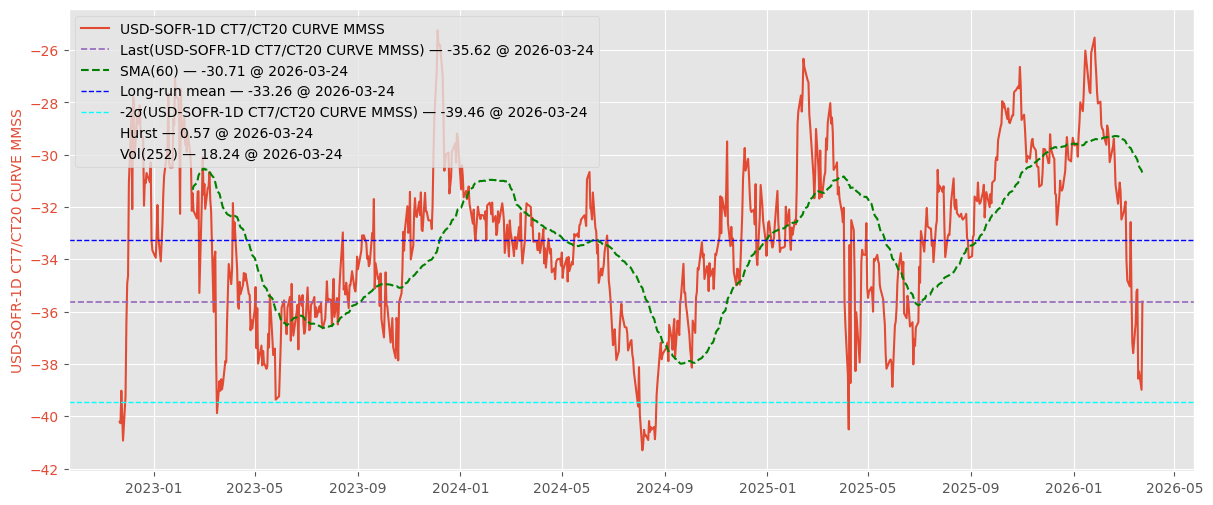

In [5]:
start = NYC_tz.localize(datetime.datetime(2022, 11, 20, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 3, 24, 17, 00))

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			# value=UnifiedValue.IRS_SPREADOVER,
			value=UnifiedValue.IRS_MMSS,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			value=UnifiedValue.IRS_SPREADOVER,
		)
		# UnifiedQuery(
		# 	cusip="CT10",
		# 	value=UnifiedValue.FRB_YTM,
		# )
	],
    n_jobs=12,
	  routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
    },
)
df

# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot, fig, ax, ax2, legend = make_secondary_axis_plot()

plot(
    df["USD-SOFR-1D CT7/CT20 CURVE MMSS"],
    which="left",
    indicators=[
        {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        {"kind": "sma", "window": 60, "style": {"linestyle": "--", "color": "green"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "blue"}},
		{"kind": "hurst", "hide": True},
		{"kind": "vol", "returns": "normal", "window": 252, "hide": True},
		{
            "kind": "full_sigma",
            "n": 2,
            "hide_center": True,
            "hide_upper": True,
            "hide_lower": False,
            "style_upper": {"linestyle": "--", "color": "cyan"},
            "style_lower": {"linestyle": "--", "color": "cyan"},
        },
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
)
# plot(df["USD-SOFR-1D 10y/30y CURVE RATE"], which="left")
# plot(df["USD-SOFR-1D 30y OUTRIGHT RATE"], which="right")
legend(show_date=True, loc="upper left")
plt.show()